In [124]:
import tensorflow_datasets as tfds
import tqdm
import numpy as np
from PIL import Image
from IPython import display
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

PATH = "./tf_datasets/columbia_cairlab_pusht_real/0.1.0"

In [125]:
# !gsutil -m cp -r gs://gdm-robotics-open-x-embodiment/columbia_cairlab_pusht_real ~/tensorflow_dataset/s/
# !pip install tfds-nightly   # to get most up-to-date registered datasets
# !pip install apache_beam

In [126]:
# Load builder from local directory
builder = tfds.builder_from_directory(builder_dir=PATH)

# Full train split; you can slice if you want (e.g. "train[:10]")
ds = builder.as_dataset(split="train")

episodes_displacements = {}  # ep_idx -> dict with 'instruction' and 'displacements'

for ep_idx, episode in enumerate(ds):
    # episode["steps"] is a tf.data.Dataset of step dicts
    step_ds = episode["steps"]

    disps = []

    # Convert steps to numpy for easy use
    for step in tfds.as_numpy(step_ds):
      # world_vector is shape (3,) float32: [dx, dy, dz]
        dv = step["action"]["world_vector"]  # numpy array of shape (3,)
        disps.append(dv)

    # Convert list of (3,) arrays to (T, 3) array
    disps = np.stack(disps, axis=0)  # shape (T, 3)

    episodes_displacements[ep_idx] = disps


In [127]:
def disps_to_positions(disps):
    """
    disps: (T, 3) or (T, 2)
    returns positions: (T+1, D) with pos[0] = 0
    """
    # cumulative sum of displacements
    pos = np.concatenate(
        [np.zeros((1, disps.shape[1]), dtype=disps.dtype),
         np.cumsum(disps, axis=0)],
        axis=0
    )
    return pos

def rdp_segment_indices(points, eps):
    """
    points: (N, 2) or (N, 3)
    eps: max allowed perpendicular distance
    return: sorted list of indices to KEEP (key points), at least [0, N-1]
    """
    N = points.shape[0]
    
    def _rdp_rec(start, end, keep):
        if end <= start + 1:
            return
        
        p_start = points[start]
        p_end   = points[end]
        seg = p_end - p_start
        seg_norm = np.linalg.norm(seg)
        
        if seg_norm < 1e-9:
            # nearly identical points
            return
        
        # perpendicular distances to segment
        v = points[start+1:end] - p_start  # (M, D)
        # projection length (scalar) onto seg
        t = np.dot(v, seg) / (seg_norm**2)
        proj = np.outer(t, seg)            # (M, D)
        perp = v - proj
        dists = np.linalg.norm(perp, axis=1)
        
        max_idx = np.argmax(dists)
        max_dist = dists[max_idx]
        
        if max_dist > eps:
            # split at this point
            idx = start + 1 + max_idx
            keep.add(idx)
            _rdp_rec(start, idx, keep)
            _rdp_rec(idx, end, keep)
        else:
            # no need to split; straight enough
            return
    
    keep = {0, N-1}
    _rdp_rec(0, N-1, keep)
    return sorted(list(keep))

def segments_from_key_idxs(key_idxs, T):
    """
    key_idxs: indices over positions (0..T)
    T: number of displacements (positions length = T+1)
    returns: list of (start_t, end_t) for displacements
             where each segment is disps[start_t:end_t]  (end_t exclusive)
    """
    segments = []
    for a, b in zip(key_idxs[:-1], key_idxs[1:]):
        start_t = a
        end_t   = b  # because disps[t] moves from pos[t] -> pos[t+1]
        segments.append((start_t, end_t))
    return segments

def filter_segments(segments, disps,
                    min_len=5,
                    min_total_disp=0.01):
    """
    Remove tiny or too-short segments.
    disps: (T, 3)
    segments: list of (s,e)
    """
    good = []
    for (s, e) in segments:
        L = e - s
        if L < min_len:
            continue
        disp_vec = disps[s:e, :2].sum(axis=0)
        if np.linalg.norm(disp_vec) < min_total_disp:
            continue
        good.append((s, e))
    return good

def segment_direction_ok(disps, s, e, max_angle_deg=60):
    """
    Check that direction doesn't change too abruptly inside segment.
    """
    v = disps[s:e, :2]  # 2D
    norms = np.linalg.norm(v, axis=1, keepdims=True) + 1e-9
    u = v / norms
    dots = (u[:-1] * u[1:]).sum(axis=1)
    dots = np.clip(dots, -1.0, 1.0)
    angles = np.degrees(np.arccos(dots))
    return np.max(angles) <= max_angle_deg

def plot_trajectory_segments(disps, segments, title=None):
    """
    disps: (T, 3) array for a single episode
    segments: list of (start_t, end_t) indices
    """
    # Work in 2D for PushT
    pos = disps_to_positions(disps[:, :2])  # (T+1, 2)

    plt.figure(figsize=(6, 6))

    # Plot full trajectory (light)
    plt.plot(pos[:, 0], pos[:, 1], linestyle='--', alpha=0.3, label='full traj')

    # Color map for segments
    cmap = plt.get_cmap('tab20')
    num_seg = len(segments)

    for i, (s, e) in enumerate(segments):
        seg_pos = pos[s:e+1]  # positions along this segment
        color = cmap(i % 20)

        plt.plot(seg_pos[:, 0], seg_pos[:, 1], linewidth=2.5, color=color)

        # Mark start & end
        plt.scatter(seg_pos[0, 0], seg_pos[0, 1], marker='o', color=color)
        plt.scatter(seg_pos[-1, 0], seg_pos[-1, 1], marker='x', color=color)

        # Label segment id at its midpoint
        mid_idx = (s + e) // 2
        mid_pos = pos[mid_idx]
        plt.text(mid_pos[0], mid_pos[1], str(i),
                 fontsize=9, color=color,
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.7))

    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlabel('x (world)')
    plt.ylabel('y (world)')
    if title is not None:
        plt.title(title)
    else:
        plt.title('Trajectory with segmented subtrajectories')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def visualize_episode_segments(episodes_displacements,
                               ep_idx,
                               eps=0.01,
                               filter=True,
                               enforce_smooth=True,
                               min_len=5,
                               min_total_disp=0.01,
                               max_angle_deg=60,method="rdp"):
    """
    episodes_displacements: dict[ep_idx] -> (T, 3)
    ep_idx: which episode to visualize
    """
    disps = episodes_displacements[ep_idx]  # (T, 3)
    T = disps.shape[0]

    # Positions for RDP (2D)
    positions = disps_to_positions(disps[:, :2])  # (T+1, 2)
    if method=="rdp":
        # 1) RDP to get keypoints
        key_idxs = rdp_segment_indices(positions, eps=eps)
        # 2) raw segments

        segments = segments_from_key_idxs(key_idxs, T)
        print("segments legth before filtering:", len(segments))

    elif method=="curvature":
            x = positions[:, 0]
            y = positions[:, 1]
            key_idxs=curvature_based_segmentation(x, y, vizualization=False)
            segments = segments_from_key_idxs(key_idxs, T)

    if filter:
    # 3) filter small/weak segments
        segments = filter_segments(segments, disps,
                                min_len=min_len,
                                min_total_disp=min_total_disp)
        print("segments length after filtering:", len(segments))

    if enforce_smooth:
        # 4) enforce direction smoothness
        final_segments = []
        for s, e in segments:
            if segment_direction_ok(disps, s, e, max_angle_deg=max_angle_deg):
                final_segments.append((s, e))
        segments = final_segments
        print("segments length after direction filtering:", len(segments))

    # 5) visualize
    title = f"Episode {ep_idx} — {len(segments)} segments"
    plot_trajectory_segments(disps, segments, title=title)

def curvature_based_segmentation(x, y, vizualization=False):
    """
    Segmente une trajectoire 2D définie par les coordonnées x et y en utilisant la courbure.
    
    Args:
        x (np.ndarray): Coordonnées x de la trajectoire.
        y (np.ndarray): Coordonnées y de la trajectoire.
        
    Returns:
        segment_indices (np.ndarray): Indices des points de coupure basés sur la courbure.
    """
    # --- 1. Préparation des Données ---    
    import numpy as np
    from scipy.signal import find_peaks
    import matplotlib.pyplot as plt


    path = np.array([x, y]).T
    N = len(path)

    # --- 2. Calcul de la Courbure (Approximation par Dérivées Numériques) ---

    # Calcul des dérivées premières (vitesse)
    dx = np.gradient(x)
    dy = np.gradient(y)

    # Calcul des dérivées secondes (accélération)
    ddx = np.gradient(dx)
    ddy = np.gradient(dy)

    # Formule de la Courbure Kappa (pour une courbe paramétrée en 2D)
    # kappa = |x'y'' - y'x''| / (x'^2 + y'^2)^(3/2)
    curvature = np.abs(dx * ddy - dy * ddx) / (dx**2 + dy**2)**(3/2)

    # Remplacer les valeurs NaN (aux extrémités où les dérivées sont moins précises)
    curvature = np.nan_to_num(curvature)

    # --- 3. Logique de Segmentation (Détection de Pics) ---

    # Trouver les indices où la courbure présente des pics significatifs.
    # On utilise un seuil (height) pour ne retenir que les virages nets.
    # La 'distance' entre les pics évite de détecter des pics voisins.
    peaks, _ = find_peaks(curvature, height=10, distance=5) 

    # Ajouter le point de départ et d'arrivée pour le découpage
    segment_indices = np.concatenate([[0], peaks, [N - 1]])
    segment_indices = np.unique(segment_indices) # Assure l'unicité et l'ordre



    # --- 4. Visualisation de la Segmentation ---
    if vizualization:
        # plt.figure(figsize=(10, 6))
        cmap = plt.get_cmap('tab20')
        plt.figure(figsize=(6, 6))
        plt.gca().set_aspect('equal', adjustable='box')
        plt.plot(x, y, color='lightblue', linestyle='--')
        plt.plot(x[segment_indices], y[segment_indices], 'ro')
        plt.plot(x, y, color='lightblue', linestyle='--')
        plt.plot(x[segment_indices], y[segment_indices], 'ro')

        # Tracer les segments (optionnel)
        for i in range(len(segment_indices) - 1):
            color = cmap(i % 20)
            start = segment_indices[i]
            end = segment_indices[i+1]
            plt.plot(x[start:end+1], y[start:end+1], linewidth=3, alpha=0.7,color=color)
            mid_idx = (start + end) // 2
            mid_posx = x[mid_idx]
            mid_posy = y[mid_idx]

            plt.text(mid_posx, mid_posy, str(i),
                        fontsize=9, color=color,
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.7))

        plt.title("Segmentation Basée sur la Courbure")
        plt.xlabel("Position X")
        plt.ylabel("Position Y")
        plt.legend()
        plt.grid(True)
        plt.show()
        

        print(f"Indices de coupure détectés : {segment_indices}")
    
    return segment_indices

segments legth before filtering: 33


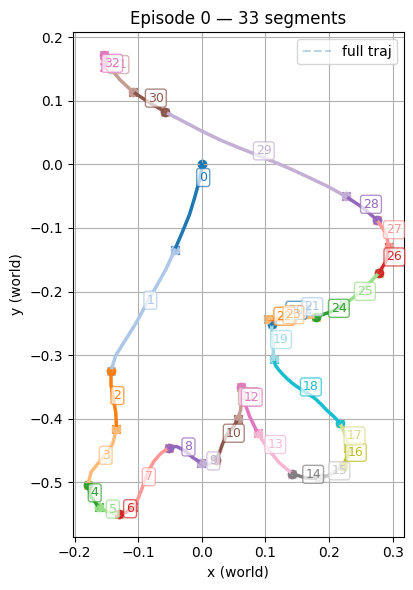

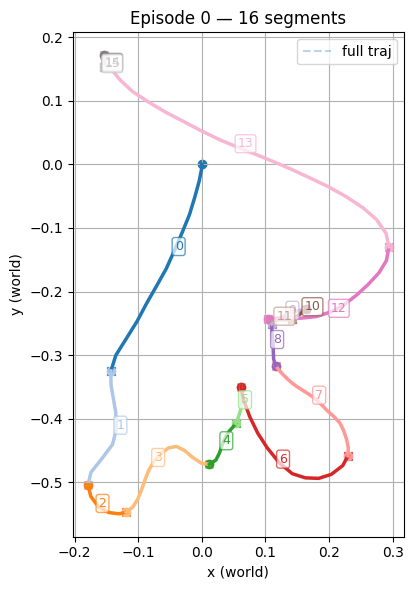

In [128]:
visualize_episode_segments(episodes_displacements, ep_idx=0, filter=False, enforce_smooth=False, eps=0.01)
visualize_episode_segments(episodes_displacements, ep_idx=0, filter=False, enforce_smooth=False, eps=0.01,method="curvature")

In [129]:
# Extract all subtrajectories from the dataset

def extract_all_subtrajectories(episodes_displacements, eps=0.01, filter=False,
                               enforce_smooth=False,
                               min_len=5,
                               min_total_disp=0.01,
                               max_angle_deg=60, use_xy_only=True,method="DP"):
    """
    episodes_displacements: dict[ep_idx] -> (T, 3) displacements
    eps: RDP epsilon
    use_xy_only: if True, segment in 2D (x,y) space

    returns:
      subtrajs: list of np.ndarrays of shape (L_i, D)  (displacements)
      meta:     list of dicts with episode index and time indices for each subtraj
    """
    all_subtrajs = []
    all_meta     = []

    for ep_idx, disps in episodes_displacements.items():
        T, D = disps.shape

        # Positions for RDP (2D or 3D)
        if use_xy_only:
            positions = disps_to_positions(disps[:, :2])  # (T+1, 2)
        else:
            positions = disps_to_positions(disps)          # (T+1, D)

        if method=="DP":
        # 1) RDP keypoints
            key_idxs = rdp_segment_indices(positions, eps=eps)

            # 2) time segments
            segments = segments_from_key_idxs(key_idxs, T)

            if filter:
            # 3) filter small/weak segments
                segments = filter_segments(segments, disps,
                                        min_len=min_len,
                                        min_total_disp=min_total_disp)
                #print("segments length after filtering:", len(segments))

            if enforce_smooth:
                # 4) enforce direction smoothness
                final_segments = []
                for s, e in segments:
                    if segment_direction_ok(disps, s, e, max_angle_deg=max_angle_deg):
                        final_segments.append((s, e))
                segments = final_segments
                print("segments length after direction filtering:", len(segments))


        elif method=="curvature":
            x = positions[:, 0]
            y = positions[:, 1]
            key_idxs=curvature_based_segmentation(x, y, vizualization=False)
            segments = segments_from_key_idxs(key_idxs, T)
  


        # 3) collect subtrajectories
        for (s, e) in segments:
            subtraj = disps[s:e]   # (L, D)
            all_subtrajs.append(subtraj)
            all_meta.append({
                "episode": ep_idx,
                "start_t": s,
                "end_t": e
            })

    return all_subtrajs, all_meta

In [130]:
all_subtrajs, all_meta = extract_all_subtrajectories(episodes_displacements, eps=0.01, use_xy_only=True, method="curvature")
print(len(all_subtrajs), "subtrajectories total")
print(all_meta[0], all_subtrajs[0].shape)
print(all_subtrajs[0])

2662 subtrajectories total
{'episode': 0, 'start_t': 0, 'end_t': 14} (14, 3)
[[-2.35729181e-04  3.46552079e-05  0.00000000e+00]
 [-6.43605745e-05 -6.13791822e-03  0.00000000e+00]
 [-3.95408459e-03 -2.00672355e-02  0.00000000e+00]
 [-6.87524024e-03 -2.51260176e-02  0.00000000e+00]
 [-8.40447098e-03 -2.76479200e-02  0.00000000e+00]
 [-1.11666108e-02 -2.74375230e-02  0.00000000e+00]
 [-1.22035788e-02 -2.83297393e-02  0.00000000e+00]
 [-1.32332025e-02 -2.94659697e-02  0.00000000e+00]
 [-1.51430368e-02 -2.70028654e-02  0.00000000e+00]
 [-1.60367917e-02 -2.80755125e-02  0.00000000e+00]
 [-1.46422312e-02 -2.75504328e-02  0.00000000e+00]
 [-1.76687930e-02 -2.83966921e-02  0.00000000e+00]
 [-1.57611817e-02 -2.50646230e-02  0.00000000e+00]
 [-7.65535887e-03 -2.46636420e-02  0.00000000e+00]]


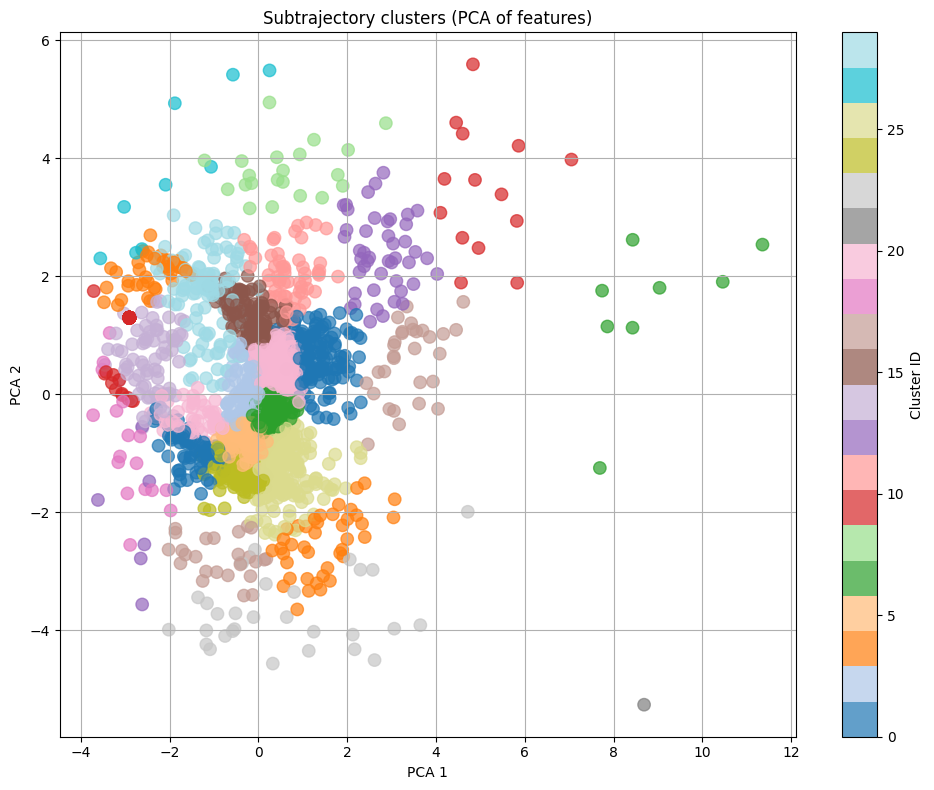

Cluster 0: 138 members
  Example features: [0.94062411 0.12812105 0.74029702 0.67227993 0.         0.03271859
 0.04011115 0.        ]
  Example episode: {'episode': 1, 'start_t': 30, 'end_t': 41}

Cluster 1: 93 members
  Example features: [ 0.72686375  0.25506214 -0.00458639 -0.99998948  0.         -0.03743222
 -0.09496764  0.        ]
  Example episode: {'episode': 0, 'start_t': 58, 'end_t': 70}

Cluster 2: 106 members
  Example features: [0.65326959 0.05668268 0.87840089 0.4779245  0.         0.00530067
 0.00519789 0.        ]
  Example episode: {'episode': 0, 'start_t': 14, 'end_t': 22}

Cluster 3: 40 members
  Example features: [ 0.23165801  0.04206598 -0.52178844  0.8530748   0.         -0.01134125
  0.00363883  0.        ]
  Example episode: {'episode': 3, 'start_t': 90, 'end_t': 99}

Cluster 4: 41 members
  Example features: [ 0.93571098  0.4700712   0.92020673 -0.3914327   0.          0.18256007
 -0.11185018  0.        ]
  Example episode: {'episode': 5, 'start_t': 201, 'end_t'

In [131]:
# --- Visualize clusters in feature space ---
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
pca = PCA(n_components=2)
proj = pca.fit_transform(features_scaled)
plt.figure(figsize=(10, 8))
plt.scatter(proj[:, 0], proj[:, 1], c=cluster_labels, cmap='tab20', s=80, alpha=0.7)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Subtrajectory clusters (PCA of features)')
plt.colorbar(label='Cluster ID')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Print cluster summary ---
for cluster_id in range(n_clusters):
    idxs = np.where(cluster_labels == cluster_id)[0]
    print(f"Cluster {cluster_id}: {len(idxs)} members")
    if len(idxs) > 0:
        print("  Example features:", features[idxs[0]])
        print("  Example episode:", all_meta[idxs[0]])
    print()

In [132]:
from scipy.spatial.distance import euclidean
from dtaidistance import dtw
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import numpy as np
from sklearn.cluster import KMeans


# --- Feature extraction helpers ---
def center_and_align(subtraj):
    """
    Center subtrajectory at origin and rotate so start->end aligns with +X axis.
    subtraj: (L, D) array
    returns: (L, D) aligned array
    """
    # Center
    centered = subtraj - subtraj[0]
    # Compute start->end vector
    v = centered[-1] - centered[0]
    norm = np.linalg.norm(v)
    if norm < 1e-9:
        return centered  # degenerate, no rotation
    # Only rotate in XY
    angle = np.arctan2(v[1], v[0])
    rot = np.array([[np.cos(-angle), -np.sin(-angle)], [np.sin(-angle), np.cos(-angle)]])
    if centered.shape[1] == 2:
        aligned = centered @ rot.T
    else:
        rot3d = np.eye(3)
        rot3d[:2, :2] = rot
        aligned = centered @ rot3d.T
    return aligned

def compute_features(subtraj):
    """
    Compute features: linearity, length, orientation, barycenter.
    subtraj: (L, D) array
    returns: feature vector (shape, amplitude, direction, barycenter)
    """
    aligned = center_and_align(subtraj)
    # Positions
    pos = np.vstack([np.zeros(aligned.shape[1]), np.cumsum(aligned, axis=0)])
    start = pos[0]
    end = pos[-1]
    direct_dist = np.linalg.norm(end - start)
    arc_length = np.sum(np.linalg.norm(np.diff(pos, axis=0), axis=1))
    linearity = direct_dist / arc_length if arc_length > 1e-9 else 0.0
    length = arc_length
    orientation = (end - start) / (np.linalg.norm(end - start) + 1e-9)
    barycenter = pos.mean(axis=0)
    # Compose feature vector
    features = np.concatenate([
        [linearity],
        [length],
        orientation,
        barycenter
    ])
    return features

def normalize_subtraj(subtraj):
    """
    Normalize a subtrajectory to unit length and zero-mean.
    subtraj: (L, D) array
    returns: (L, D) normalized array
    """
    # Zero-mean per dimension
    subtraj = subtraj - subtraj.mean(axis=0)
    # Unit norm (L2 norm over all elements)
    norm = np.linalg.norm(subtraj)
    if norm > 1e-9:
        subtraj = subtraj / norm
    return subtraj

def pad_subtraj(subtraj, max_len):
    """
    Pad a subtrajectory to max_len by repeating last row.
    subtraj: (L, D) array
    max_len: target length
    returns: (max_len, D) padded array
    """
    if subtraj.shape[0] >= max_len:
        return subtraj[:max_len]
    pad_rows = max_len - subtraj.shape[0]
    padding = np.repeat(subtraj[-1:], pad_rows, axis=0)
    return np.vstack([subtraj, padding])

def compute_pairwise_dtw_distance(subtrajs, normalized=True, max_len=None):
    """
    Compute pairwise DTW distance between subtrajectories.
    subtrajs: list of (L_i, D) arrays
    normalized: if True, normalize each subtrajectory first
    max_len: if provided, pad all to this length; else use max length in dataset
    returns: (N, N) distance matrix (symmetric)
    """
    N = len(subtrajs)
    
    if max_len is None:
        max_len = max([s.shape[0] for s in subtrajs])
    
    # Preprocess: normalize and pad
    processed = []
    for s in subtrajs:
        if normalized:
            s = normalize_subtraj(s)
        s = pad_subtraj(s, max_len)
        processed.append(s.flatten())  # flatten to 1D for DTW
    
    # Compute pairwise DTW distances
    dist_matrix = np.zeros((N, N))
    for i in range(N):
        for j in range(i + 1, N):
            d = dtw.distance(processed[i], processed[j])
            dist_matrix[i, j] = d
            dist_matrix[j, i] = d
    
    return dist_matrix

def compute_pairwise_euclidean_distance(subtrajs, normalized=True, max_len=None):
    """
    Compute pairwise Euclidean distance between subtrajectories.
    Simpler and faster than DTW; works well for similar-length trajectories.
    subtrajs: list of (L_i, D) arrays
    normalized: if True, normalize each subtrajectory first
    max_len: if provided, pad all to this length
    returns: (N, N) distance matrix (symmetric)
    """
    N = len(subtrajs)
    
    if max_len is None:
        max_len = max([s.shape[0] for s in subtrajs])
    
    # Preprocess: normalize, pad, flatten
    processed = []
    for s in subtrajs:
        if normalized:
            s = normalize_subtraj(s)
        s = pad_subtraj(s, max_len)
        processed.append(s.flatten())
    
    processed = np.array(processed)  # (N, max_len*D)
    
    # Compute pairwise Euclidean distances
    from scipy.spatial.distance import pdist, squareform
    dist_matrix = squareform(pdist(processed, metric='euclidean'))
    
    return dist_matrix

def cluster_subtrajectories(all_subtrajs, all_meta, n_clusters=10, method='euclidean', normalized=True, max_len=None):
    """
    Cluster subtrajectories using KMeans on pairwise distances.
    all_subtrajs: list of (L_i, D) arrays (subtrajectories)
    all_meta: list of dicts with metadata
    n_clusters: number of clusters
    method: 'euclidean' or 'dtw'
    normalized: if True, normalize before distance computation
    max_len: if provided, pad all to this length
    
    returns:
      cluster_labels: (N,) array of cluster assignments
      cluster_centers_idx: list of indices of closest subtraj to each cluster center
      dist_matrix: (N, N) pairwise distance matrix
    """
    print(f"Computing {method} distances for {len(all_subtrajs)} subtrajectories...")
    
    if method == 'euclidean':
        dist_matrix = compute_pairwise_euclidean_distance(all_subtrajs, normalized=normalized, max_len=max_len)
    elif method == 'dtw':
        dist_matrix = compute_pairwise_dtw_distance(all_subtrajs, normalized=normalized, max_len=max_len)
    elif method=='featured':
        features = np.array([compute_features(s) for s in all_subtrajs])

        # Scale features if desired
        if normalized:   # or scale_features
            scaler = StandardScaler()
            features = scaler.fit_transform(features)

        # Keep name 'dist_matrix' for compatibility but here it is not a distance matrix
        dist_matrix = features
    else:
        raise ValueError(f"Unknown method: {method}")
    
    print(f"Clustering {len(all_subtrajs)} subtrajectories into {n_clusters} clusters...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(dist_matrix)
    
    # Find representative (closest to center) for each cluster
    cluster_centers_idx = []
    for cluster_id in range(n_clusters):
        member_indices = np.where(cluster_labels == cluster_id)[0]
        if len(member_indices) > 0:
            # Find member closest to cluster center
            if method == 'featured':
                distances = kmeans.transform(features)
                closest_idx =member_indices[np.argmin(distances[member_indices, cluster_id])]
                cluster_centers_idx.append(closest_idx)
            else:
                center = dist_matrix[member_indices][:, member_indices].mean(axis=1)
                closest_idx = member_indices[np.argmin(center)]
                cluster_centers_idx.append(closest_idx)
        
    return cluster_labels, cluster_centers_idx, dist_matrix

def cluster_subtrajectories_fit(all_subtrajs, all_meta, n_clusters=10, method='euclidean', normalized=True, max_len=None):
    """
    Cluster subtrajectories using KMeans on pairwise distances.
    all_subtrajs: list of (L_i, D) arrays (subtrajectories)
    all_meta: list of dicts with metadata
    n_clusters: number of clusters
    method: 'euclidean' or 'dtw'
    normalized: if True, normalize before distance computation
    max_len: if provided, pad all to this length
    
    returns:
      cluster_labels: (N,) array of cluster assignments
      cluster_centers_idx: list of indices of closest subtraj to each cluster center
      dist_matrix: (N, N) pairwise distance matrix
    """
    print(f"Computing {method} distances for {len(all_subtrajs)} subtrajectories...")
    
    if method == 'euclidean':
        dist_matrix = compute_pairwise_euclidean_distance(all_subtrajs, normalized=normalized, max_len=max_len)
    elif method == 'dtw':
        dist_matrix = compute_pairwise_dtw_distance(all_subtrajs, normalized=normalized, max_len=max_len)
    elif method=='featured':
        features = np.array([compute_features(s) for s in all_subtrajs])

        # Scale features if desired
        if normalized:   # or scale_features
            scaler = StandardScaler()
            features = scaler.fit_transform(features)

        # Keep name 'dist_matrix' for compatibility but here it is not a distance matrix
        dist_matrix = features
    else:
        raise ValueError(f"Unknown method: {method}")
    
    print(f"Clustering {len(all_subtrajs)} subtrajectories into {n_clusters} clusters...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    return kmeans.fit(dist_matrix)
    
   

def visualize_clusters(all_subtrajs, cluster_labels, n_samples=None,method="t-SNE",normalized=True):
    """
    Visualize clusters using t-SNE on flattened, normalized subtrajectories.
    all_subtrajs: list of (L_i, D) arrays
    cluster_labels: (N,) cluster assignments
    n_samples: if provided, subsample this many subtrajectories for visualization
    """
    N = len(all_subtrajs)
    
    if n_samples is not None and n_samples < N:
        indices = np.random.choice(N, n_samples, replace=False)
    else:
        indices = np.arange(N)
    
    max_len = max([all_subtrajs[i].shape[0] for i in indices])
    
    # Prepare data for t-SNE
    processed = []
    labels_sub = []
    if normalized:
        for i in indices:
            s = normalize_subtraj(all_subtrajs[i])
            s = pad_subtraj(s, max_len)
            processed.append(s.flatten())
            labels_sub.append(cluster_labels[i])
        
        processed = np.array(processed)
        labels_sub = np.array(labels_sub)
    else:
        processed=all_subtrajs
        labels_sub=cluster_labels
    
    if method=="t-SNE":
        # t-SNE embedding
        print("Running t-SNE for visualization...")
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(processed) - 1))
        embedding = tsne.fit_transform(processed)
        
        # Plot
        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=labels_sub, cmap='tab20', s=100, alpha=0.7)
        plt.colorbar(scatter, label='Cluster ID')
        plt.xlabel('t-SNE 1')
        plt.ylabel('t-SNE 2')
        plt.title(f'Clustered Subtrajectories (n={len(indices)})')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    elif method=="PCA":
        from sklearn.decomposition import PCA
        pca = PCA(n_components=2)
        embedding = pca.fit_transform(processed)
        
        # Plot
        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=labels_sub, cmap='tab20', s=100, alpha=0.7)
        plt.colorbar(scatter, label='Cluster ID')
        plt.xlabel('PCA 1')
        plt.ylabel('PCA 2')
        plt.title(f'Clustered Subtrajectories (n={len(indices)})')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        

def print_cluster_summary(all_subtrajs, all_meta, cluster_labels, cluster_centers_idx):
    """
    Print summary of each cluster: size, representatives, episodes.
    """
    n_clusters = len(cluster_centers_idx)
    
    print(f"\n{'='*80}")
    print(f"Cluster Summary ({n_clusters} clusters)")
    print(f"{'='*80}\n")
    
    for cluster_id in range(n_clusters):
        member_indices = np.where(cluster_labels == cluster_id)[0]
        print(f"Cluster {cluster_id}: {len(member_indices)} members")
        
        # Show representative
        rep_idx = cluster_centers_idx[cluster_id]
        rep_meta = all_meta[rep_idx]
        rep_shape = all_subtrajs[rep_idx].shape
        print(f"  Representative: subtrajectory {rep_idx}, episode {rep_meta['episode']}, shape {rep_shape}")
        
        # Show episode distribution
        ep_counts = {}
        for idx in member_indices:
            ep = all_meta[idx]['episode']
            ep_counts[ep] = ep_counts.get(ep, 0) + 1
        print(f"  Episode distribution: {dict(sorted(ep_counts.items())[:5])}...")  # show first 5 episodes
        print()




Computing featured distances for 2662 subtrajectories...
Clustering 2662 subtrajectories into 30 clusters...
Clustered 2662 subtrajectories into 30 clusters
Cluster sizes: [138  93 106  40  41 243   8 557  21  92  14  59  45   6  76 139  25  30
  17 342  53   1  19  11  94 191  79   9  43  70]

Cluster Summary (30 clusters)

Cluster 0: 138 members
  Representative: subtrajectory 1816, episode 82, shape (9, 3)
  Episode distribution: {1: 2, 2: 4, 3: 1, 4: 1, 5: 4}...

Cluster 1: 93 members
  Representative: subtrajectory 189, episode 9, shape (10, 3)
  Episode distribution: {0: 1, 1: 1, 2: 1, 3: 1, 4: 1}...

Cluster 2: 106 members
  Representative: subtrajectory 386, episode 17, shape (5, 3)
  Episode distribution: {0: 1, 1: 1, 2: 1, 5: 1, 6: 1}...

Cluster 3: 40 members
  Representative: subtrajectory 2416, episode 110, shape (15, 3)
  Episode distribution: {3: 1, 5: 1, 6: 1, 7: 1, 17: 1}...

Cluster 4: 41 members
  Representative: subtrajectory 2086, episode 95, shape (19, 3)
  Episod

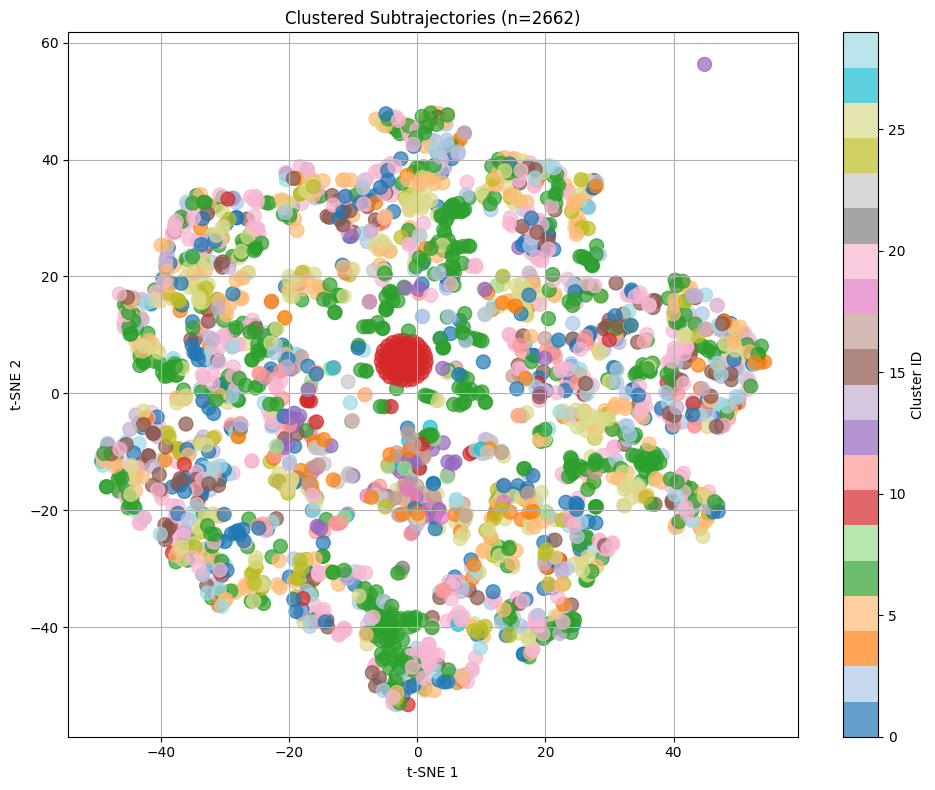

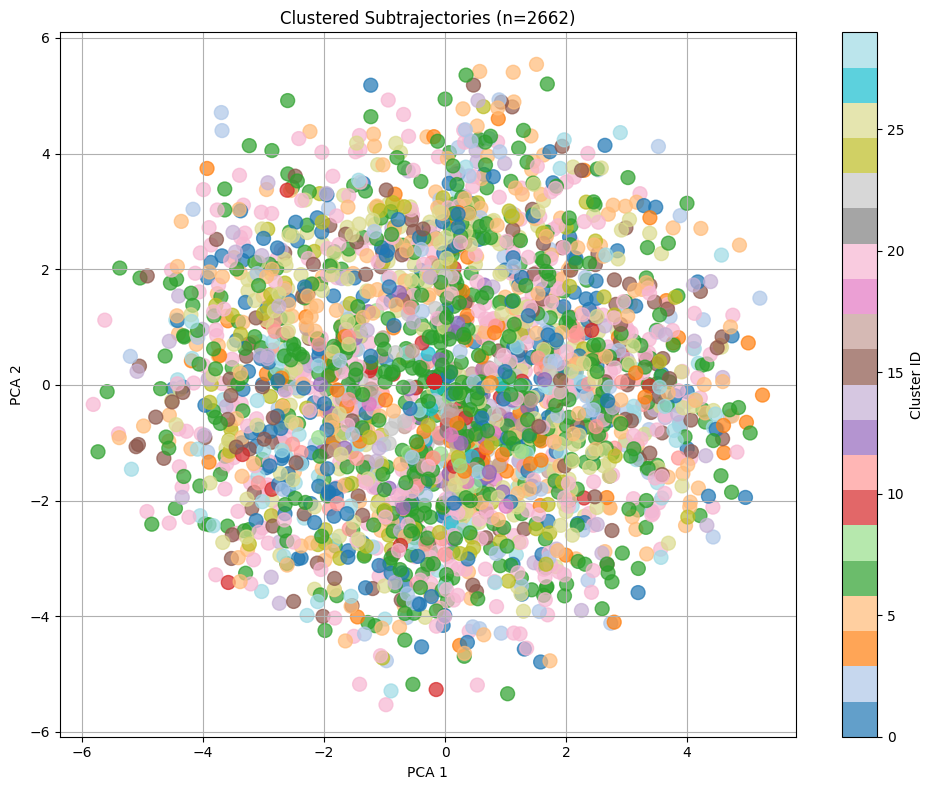

Running t-SNE for visualization...


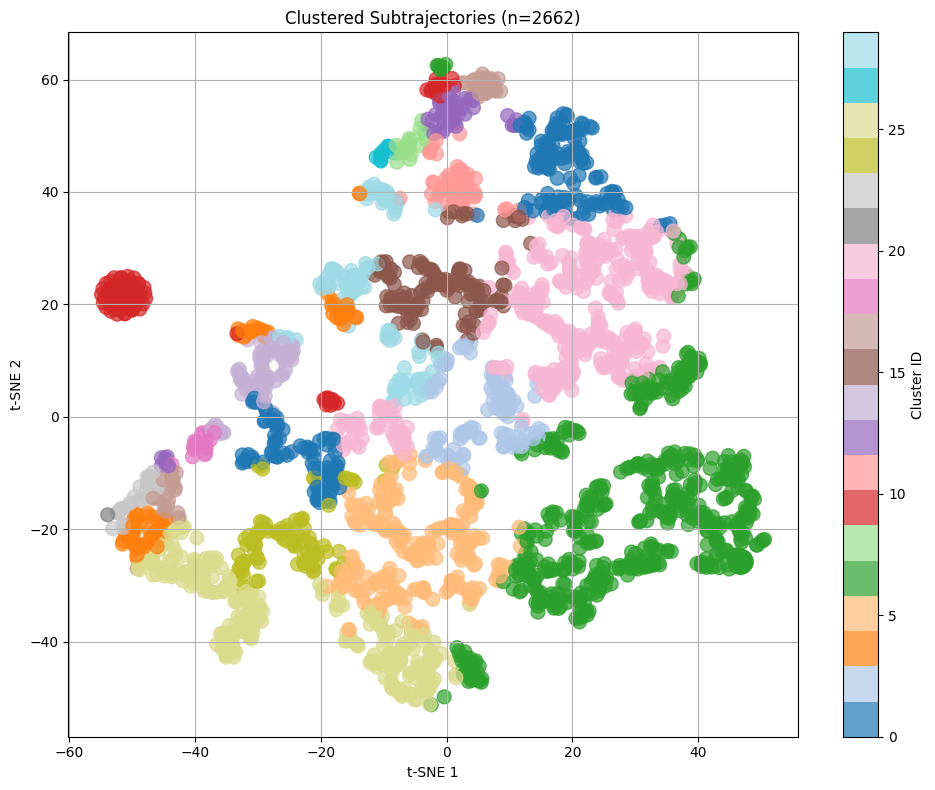

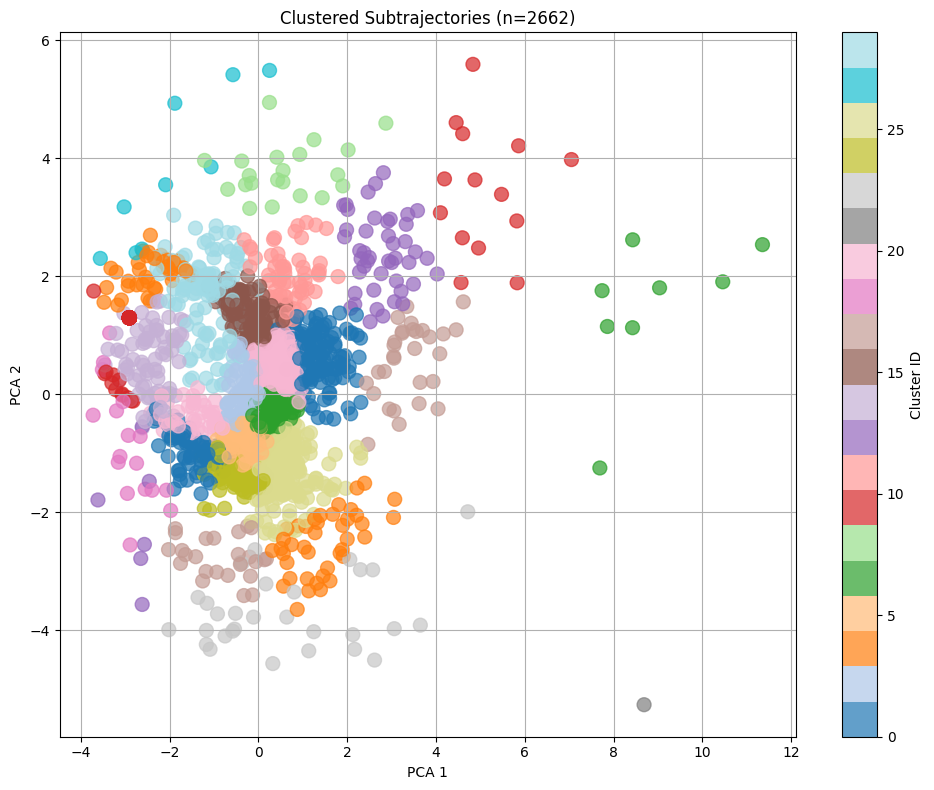

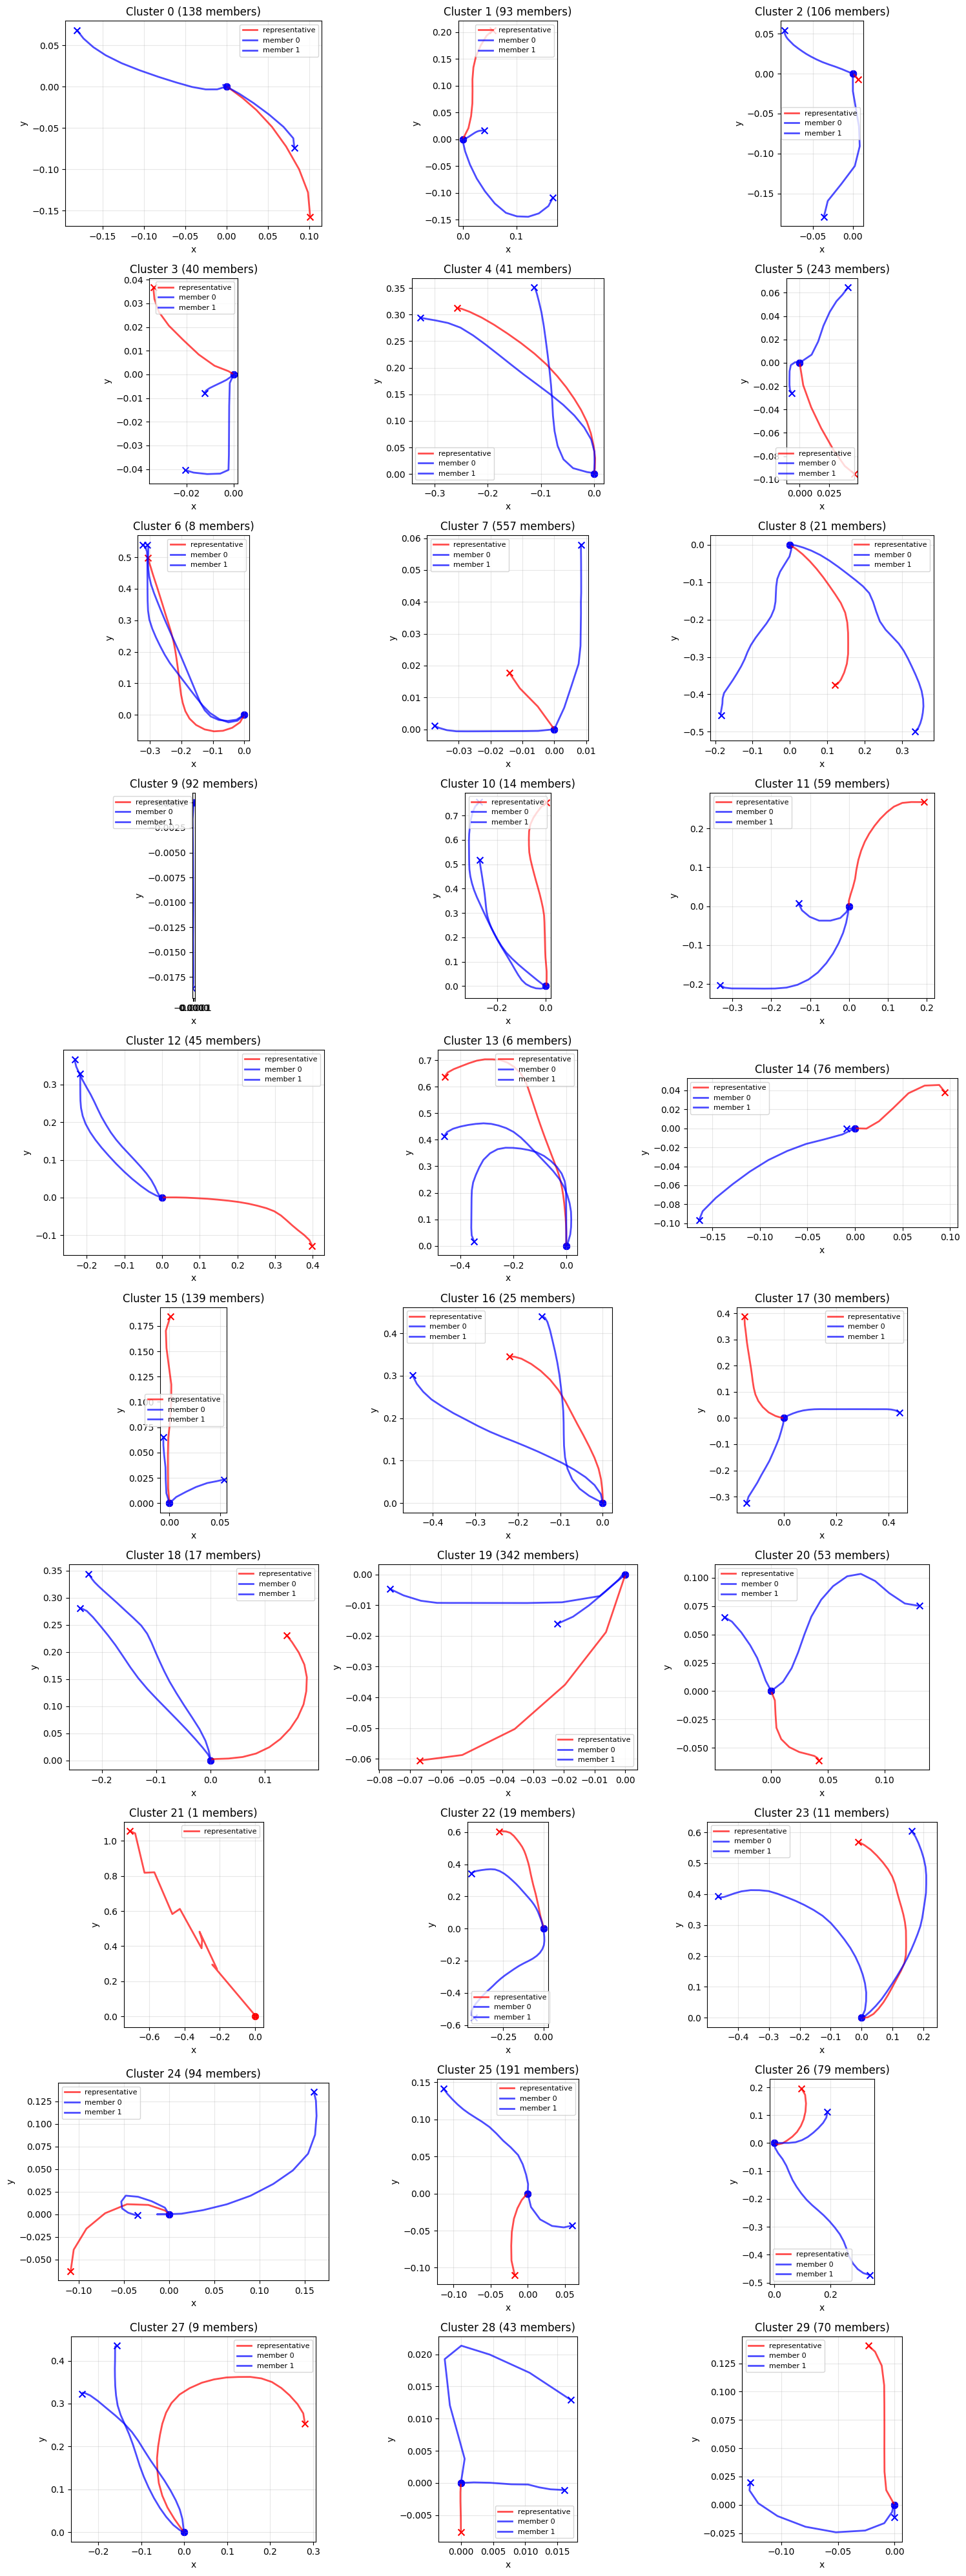

In [133]:
# featured clustering
n_clusters = 30  # adjust based on your data
cluster_labels, cluster_centers_idx, dist_matrix = cluster_subtrajectories(
    all_subtrajs, 
    all_meta, 
    n_clusters=n_clusters,
    method='featured',  # 'euclidean' is faster than 'dtw'
    normalized=True,
    max_len=None  # will auto-pad to longest subtraj
)

print(f"Clustered {len(all_subtrajs)} subtrajectories into {n_clusters} clusters")
print(f"Cluster sizes: {np.bincount(cluster_labels)}")

print_cluster_summary(all_subtrajs, all_meta, cluster_labels, cluster_centers_idx)


# visualize_clusters(dist_matrix, cluster_labels, n_samples=min(500, len(all_subtrajs)), method="t-SNE")

# Trajectories 
visualize_clusters(all_subtrajs, cluster_labels, method="t-SNE")
visualize_clusters(all_subtrajs, cluster_labels, method="PCA")
# Features
visualize_clusters(dist_matrix, cluster_labels, method="t-SNE",normalized=False)
visualize_clusters(dist_matrix, cluster_labels, method="PCA",normalized=False)

# Run visualization trajectory representations for each cluster
plot_cluster_representatives(all_subtrajs, all_meta, cluster_labels, cluster_centers_idx, n_per_cluster=3)

Computing euclidean distances for 2662 subtrajectories...
Clustering 2662 subtrajectories into 30 clusters...
Clustered 2662 subtrajectories into 30 clusters
Cluster sizes: [122 105  75  58  71 172  81  84  40  77 114  49  41 100  95 103  98  57
  83  70  30 160  98  96 107 162  63  89  69  93]

Cluster Summary (30 clusters)

Cluster 0: 122 members
  Representative: subtrajectory 1965, episode 89, shape (9, 3)
  Episode distribution: {0: 1, 2: 1, 3: 1, 5: 2, 7: 1}...

Cluster 1: 105 members
  Representative: subtrajectory 2487, episode 113, shape (10, 3)
  Episode distribution: {1: 2, 3: 1, 4: 2, 7: 1, 10: 1}...

Cluster 2: 75 members
  Representative: subtrajectory 53, episode 2, shape (8, 3)
  Episode distribution: {2: 1, 3: 1, 4: 2, 6: 1, 7: 1}...

Cluster 3: 58 members
  Representative: subtrajectory 1545, episode 70, shape (9, 3)
  Episode distribution: {3: 1, 6: 1, 11: 1, 13: 1, 16: 1}...

Cluster 4: 71 members
  Representative: subtrajectory 22, episode 1, shape (7, 3)
  Episode

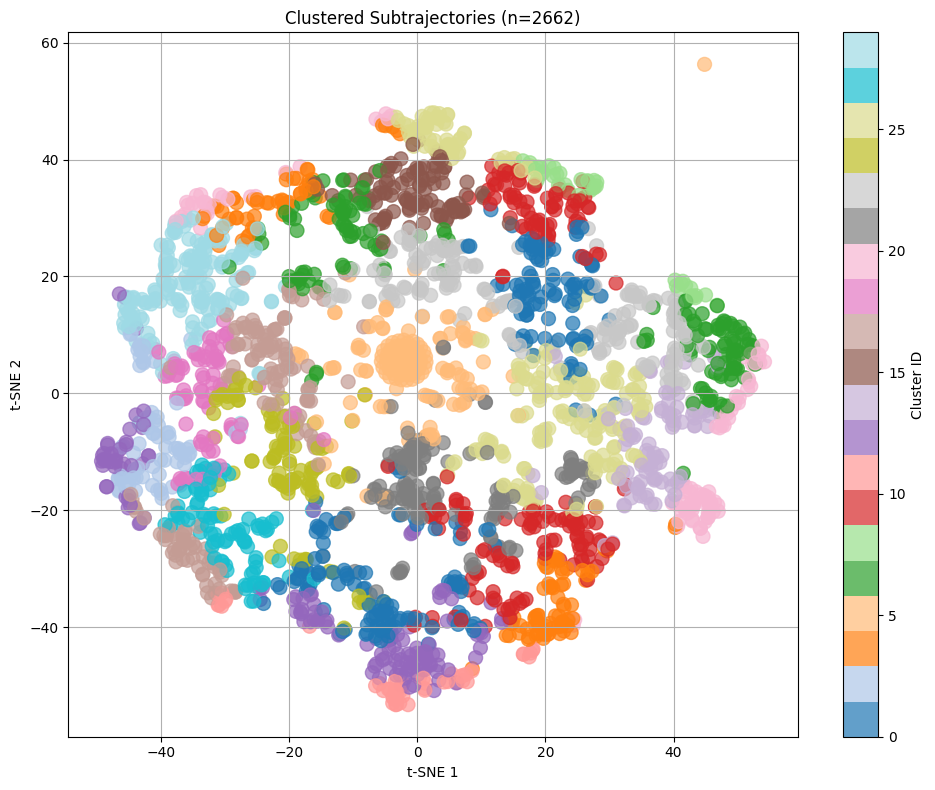

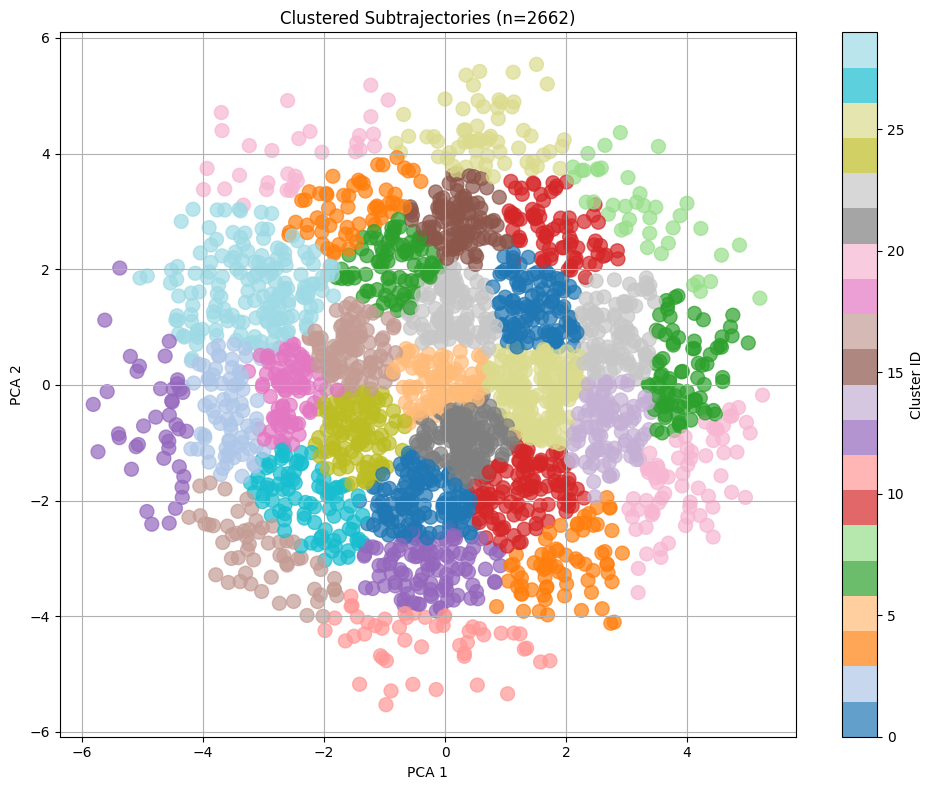

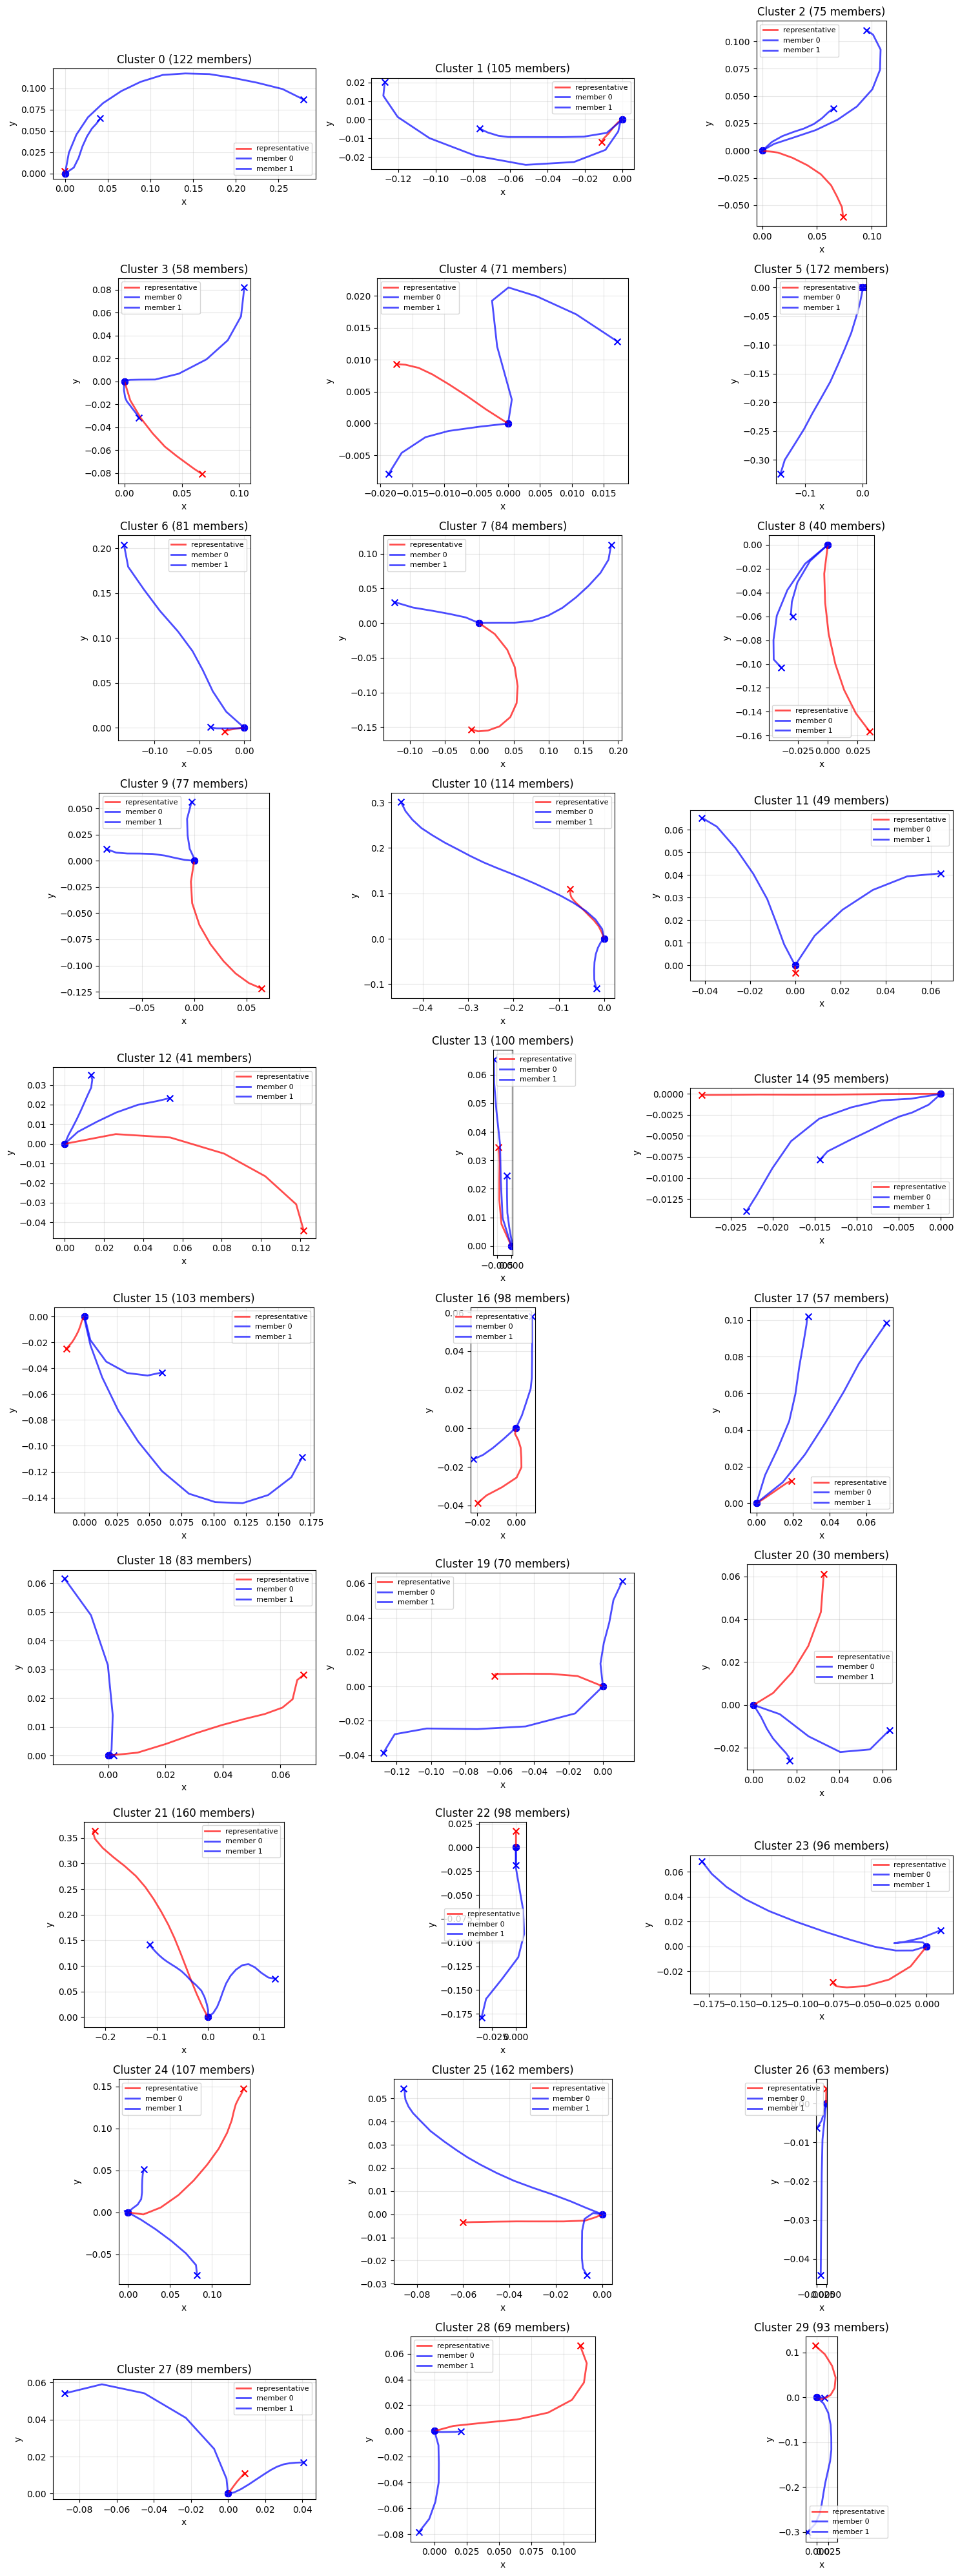

In [134]:
# Euclidian clustering
n_clusters = 30  # adjust based on your data
cluster_labels, cluster_centers_idx, dist_matrix = cluster_subtrajectories(
    all_subtrajs, 
    all_meta, 
    n_clusters=n_clusters,
    method='euclidean',  # 'euclidean' is faster than 'dtw'
    normalized=True,
    max_len=None  # will auto-pad to longest subtraj
)

print(f"Clustered {len(all_subtrajs)} subtrajectories into {n_clusters} clusters")
print(f"Cluster sizes: {np.bincount(cluster_labels)}")

print_cluster_summary(all_subtrajs, all_meta, cluster_labels, cluster_centers_idx)


# visualize_clusters(dist_matrix, cluster_labels, n_samples=min(500, len(all_subtrajs)), method="t-SNE")

# Trajectories 
visualize_clusters(all_subtrajs, cluster_labels, method="t-SNE")
visualize_clusters(all_subtrajs, cluster_labels, method="PCA")

# Run visualization trajectory representations for each cluster
plot_cluster_representatives(all_subtrajs, all_meta, cluster_labels, cluster_centers_idx, n_per_cluster=3)


In [135]:
# DTW clustering
n_clusters = 30  # adjust based on your data
cluster_labels, cluster_centers_idx, dist_matrix = cluster_subtrajectories(
    all_subtrajs, 
    all_meta, 
    n_clusters=n_clusters,
    method='dtw',  # 'euclidean' is faster than 'dtw'
    normalized=True,
    max_len=None  # will auto-pad to longest subtraj
)

print(f"Clustered {len(all_subtrajs)} subtrajectories into {n_clusters} clusters")
print(f"Cluster sizes: {np.bincount(cluster_labels)}")

print_cluster_summary(all_subtrajs, all_meta, cluster_labels, cluster_centers_idx)


# visualize_clusters(dist_matrix, cluster_labels, n_samples=min(500, len(all_subtrajs)), method="t-SNE")

# Trajectories 
visualize_clusters(all_subtrajs, cluster_labels, method="t-SNE")
visualize_clusters(all_subtrajs, cluster_labels, method="PCA")

# Run visualization trajectory representations for each cluster
plot_cluster_representatives(all_subtrajs, all_meta, cluster_labels, cluster_centers_idx, n_per_cluster=3)

# Run visualization trajectory representations for each cluster
plot_cluster_representatives(all_subtrajs, all_meta, cluster_labels, cluster_centers_idx, n_per_cluster=3)

Computing dtw distances for 2662 subtrajectories...


KeyboardInterrupt: 

In [ ]:
import json
class TrajectoryTokenizer:
    def __init__(self, n_clusters=64, random_state=42,method="featured",normalized=True):
        self.n_clusters = n_clusters
        self.kmeans = None
        self.cluster_centers_ = None
        self.n_features_ = None
        self.method=method
        self.normalized=normalized

    def fit(self, list_of_trajectories):
        self.kmeans = cluster_subtrajectories_fit(
            list_of_trajectories, 
            all_meta, 
            n_clusters=self.n_clusters,
            method=self.method,  # 'euclidean' is faster than 'dtw'
            normalized=True,
            max_len=None  # will auto-pad to longest subtraj
        )
        # self.cluster_centers_ = self.kmeans.cluster_centers_
        # self.n_features_ = dist_matrix.shape[1]
        return self

    def encode(self, pts):
        """Return token id (cluster) for a single segment (T,3)"""
        if self.method=="featured":
            fz = compute_features([pts])
        else:
            fz=[pts]
        return int(self.kmeans.predict(fz)[0])

    def batch_encode(self, list_of_segments):
        if self.method=="featured":
            Fz = np.array([compute_features(s) for s in all_subtrajs])
                  # Scale features if desired
            if self.normalized:   # or scale_features
                scaler = StandardScaler()
                Fz = scaler.fit_transform(Fz)
        else:
            Fz=list_of_segments
        
        ids = self.kmeans.predict(Fz)
        return ids

    def save(self, path_json):
        meta = {
            "n_clusters": int(self.n_clusters),
            # "cluster_centers": self.cluster_centers_.tolist(),
            # "n_features": int(self.n_features_)
        }
        with open(path_json, "w") as f:
            json.dump(meta, f, indent=2)

    def load(self, path_json):
        with open(path_json, "r") as f:
            meta = json.load(f)
        self.n_clusters = meta["n_clusters"]
        # self.cluster_centers_ = np.array(meta["cluster_centers"])
        # self.n_features_ = meta["n_features"]
        # reconstruct kmeans-like object (predict only using centers)
        class DummyKMeans:
            def __init__(self, centers):
                self.cluster_centers_ = centers
            def predict(self, X):
                # assign to nearest center (euclidean)
                d = np.linalg.norm(X[:, None, :] - self.cluster_centers_[None, :, :], axis=2)
                return np.argmin(d, axis=1)
        self.kmeans = DummyKMeans(self.cluster_centers_)
        return self



In [ ]:
# tokkenize all segments
tok = TrajectoryTokenizer(n_clusters=30)
tok.fit(all_subtrajs)
# encode all segments and show distribution
ids = tok.batch_encode(all_subtrajs)
uniq, counts = np.unique(ids, return_counts=True)
print("Cluster counts:", dict(zip(uniq.tolist(), counts.tolist())))
# save
tok.save("trajectory_vocab.json")
print("Saved vocab -> trajectory_vocab.json")

Computing featured distances for 2662 subtrajectories...
Clustering 2662 subtrajectories into 30 clusters...
Cluster counts: {0: 138, 1: 93, 2: 106, 3: 40, 4: 41, 5: 243, 6: 8, 7: 557, 8: 21, 9: 92, 10: 14, 11: 59, 12: 45, 13: 6, 14: 76, 15: 139, 16: 25, 17: 30, 18: 17, 19: 342, 20: 53, 21: 1, 22: 19, 23: 11, 24: 94, 25: 191, 26: 79, 27: 9, 28: 43, 29: 70}
Saved vocab -> trajectory_vocab.json


In [ ]:
# inspect cluster counts
for i in range(30):
    count = np.sum(ids == i)
    print(f"Cluster {i}: {count} trajectories")

Cluster 0: 138 trajectories
Cluster 1: 93 trajectories
Cluster 2: 106 trajectories
Cluster 3: 40 trajectories
Cluster 4: 41 trajectories
Cluster 5: 243 trajectories
Cluster 6: 8 trajectories
Cluster 7: 557 trajectories
Cluster 8: 21 trajectories
Cluster 9: 92 trajectories
Cluster 10: 14 trajectories
Cluster 11: 59 trajectories
Cluster 12: 45 trajectories
Cluster 13: 6 trajectories
Cluster 14: 76 trajectories
Cluster 15: 139 trajectories
Cluster 16: 25 trajectories
Cluster 17: 30 trajectories
Cluster 18: 17 trajectories
Cluster 19: 342 trajectories
Cluster 20: 53 trajectories
Cluster 21: 1 trajectories
Cluster 22: 19 trajectories
Cluster 23: 11 trajectories
Cluster 24: 94 trajectories
Cluster 25: 191 trajectories
Cluster 26: 79 trajectories
Cluster 27: 9 trajectories
Cluster 28: 43 trajectories
Cluster 29: 70 trajectories
